In [1]:
import pandas as pd

df = pd.read_csv("bank/bank-full.csv", sep=";")

print(df.shape)
df.head()

(45211, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [2]:
# Check the columns and data types
print(df.info())

print("\nTarget distribution:")
print(df["y"].value_counts())

print("\nTarget percentages:")
print(df["y"].value_counts(normalize=True) * 100)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB
None

Target distribution:
y
no     39922
yes     5289
Name: count, dtype: int64

Target percentage

In [3]:
# Set up the features and target

# Remove y because it is what we are predicting.
# Remove duration because we would not know the call length before calling.
X = df.drop(columns=["y", "duration"])

# Change yes/no into 1/0
y = df["y"].map({"yes": 1, "no": 0})

print("Number of features:", X.shape[1])
print("Number of rows:", X.shape[0])
print("Duration included:", "duration" in X.columns)

Number of features: 15
Number of rows: 45211
Duration included: False


In [4]:
# Separate numeric and categorical columns

numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("Numeric features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numeric features:
['age', 'balance', 'day', 'campaign', 'pdays', 'previous']

Categorical features:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']


In [5]:
# Split the data into training and testing sets

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

Training rows: 36168
Testing rows: 9043


In [6]:
# Prepare the numeric and categorical data

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
])

print("Preprocessing is ready.")

Preprocessing is ready.


In [7]:
# Model 1 - Logistic Regression

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

# Train the model
logistic_model.fit(X_train, y_train)

# Make predictions on the test data
logistic_predictions = logistic_model.predict(X_test)

print("Logistic Regression training complete.")

Logistic Regression training complete.


In [8]:
# Evaluate Logistic Regression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

print("Logistic Regression Results")
print("---------------------------")
print("Accuracy:", round(accuracy_score(y_test, logistic_predictions), 4))
print("Precision:", round(precision_score(y_test, logistic_predictions), 4))
print("Recall:", round(recall_score(y_test, logistic_predictions), 4))
print("F1 Score:", round(f1_score(y_test, logistic_predictions), 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, logistic_predictions))

Logistic Regression Results
---------------------------
Accuracy: 0.8933
Precision: 0.6632
Recall: 0.1786
F1 Score: 0.2815

Confusion Matrix:
[[7889   96]
 [ 869  189]]


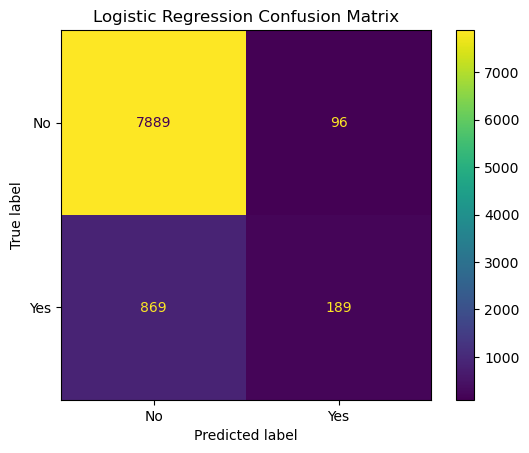

In [9]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    logistic_predictions,
    display_labels=["No", "Yes"]
)
plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [10]:
# Model 2 - Random Forest

from sklearn.ensemble import RandomForestClassifier

random_forest_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ))
])

# Train the model
random_forest_model.fit(X_train, y_train)

# Make predictions
rf_predictions = random_forest_model.predict(X_test)

print("Random Forest training complete.")

Random Forest training complete.


In [11]:
# Evaluate Random Forest

print("Random Forest Results")
print("---------------------")
print("Accuracy:", round(accuracy_score(y_test, rf_predictions), 4))
print("Precision:", round(precision_score(y_test, rf_predictions), 4))
print("Recall:", round(recall_score(y_test, rf_predictions), 4))
print("F1 Score:", round(f1_score(y_test, rf_predictions), 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, rf_predictions))

Random Forest Results
---------------------
Accuracy: 0.8937
Precision: 0.6222
Recall: 0.2335
F1 Score: 0.3395

Confusion Matrix:
[[7835  150]
 [ 811  247]]


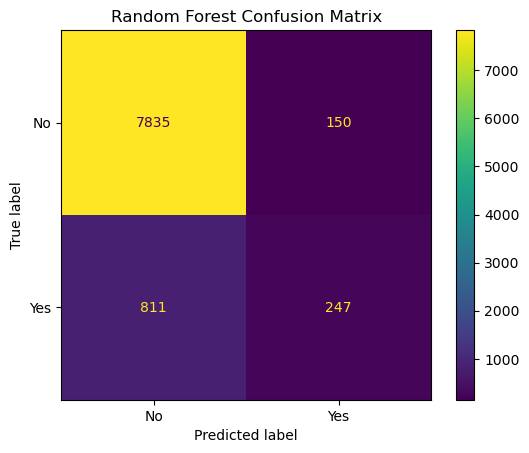

In [12]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    rf_predictions,
    display_labels=["No", "Yes"]
)
plt.title("Random Forest Confusion Matrix")
plt.show()

In [13]:
# Get the probability that each customer will subscribe

logistic_probabilities = logistic_model.predict_proba(X_test)[:, 1]
rf_probabilities = random_forest_model.predict_proba(X_test)[:, 1]

print("Probabilities are ready.")

Probabilities are ready.


In [14]:
# Test different decision thresholds

import pandas as pd

def test_thresholds(y_true, probabilities):
    results = []

    for threshold in [0.20, 0.30, 0.40, 0.50, 0.60, 0.70]:
        predictions = (probabilities >= threshold).astype(int)

        tn, fp, fn, tp = confusion_matrix(
            y_true, predictions
        ).ravel()

        results.append({
            "Threshold": threshold,
            "Precision": round(
                precision_score(y_true, predictions, zero_division=0), 4
            ),
            "Recall": round(
                recall_score(y_true, predictions, zero_division=0), 4
            ),
            "F1": round(
                f1_score(y_true, predictions, zero_division=0), 4
            ),
            "False Positives": fp,
            "False Negatives": fn,
            "True Positives": tp
        })

    return pd.DataFrame(results)

In [15]:
# Logistic Regression threshold results

logistic_threshold_results = test_thresholds(
    y_test,
    logistic_probabilities
)

logistic_threshold_results

,Threshold,Precision,Recall,F1,False Positives,False Negatives,True Positives
0,0.2,0.4637,0.4405,0.4518,539,592,466
1,0.3,0.5552,0.3327,0.4161,282,706,352
2,0.4,0.6005,0.2486,0.3516,175,795,263
3,0.5,0.6632,0.1786,0.2815,96,869,189
4,0.6,0.7135,0.1200,0.2055,51,931,127
5,0.7,0.7355,0.0841,0.1510,32,969,89


In [16]:
# Random Forest threshold results

rf_threshold_results = test_thresholds(
    y_test,
    rf_probabilities
)

rf_threshold_results

,Threshold,Precision,Recall,F1,False Positives,False Negatives,True Positives
0,0.2,0.3707,0.5718,0.4498,1027,453,605
1,0.3,0.4527,0.4480,0.4504,573,584,474
2,0.4,0.5322,0.3355,0.4116,312,703,355
3,0.5,0.6171,0.2391,0.3447,157,805,253
4,0.6,0.6996,0.1673,0.2700,76,881,177
5,0.7,0.7407,0.0945,0.1676,35,958,100


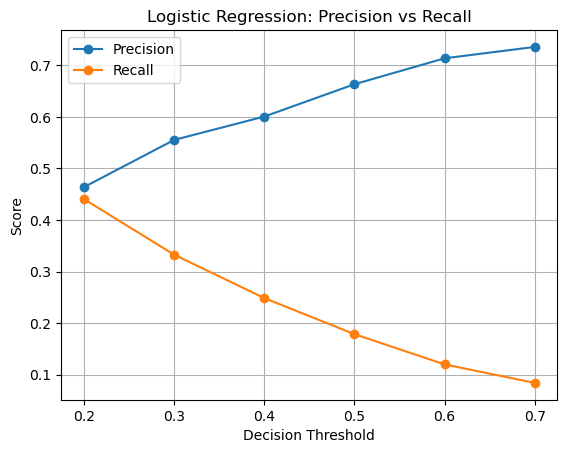

In [17]:
# Show how the threshold changes precision and recall

import matplotlib.pyplot as plt

plt.plot(
    logistic_threshold_results["Threshold"],
    logistic_threshold_results["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    logistic_threshold_results["Threshold"],
    logistic_threshold_results["Recall"],
    marker="o",
    label="Recall"
)

plt.xlabel("Decision Threshold")
plt.ylabel("Score")
plt.title("Logistic Regression: Precision vs Recall")
plt.legend()
plt.grid(True)

plt.show()

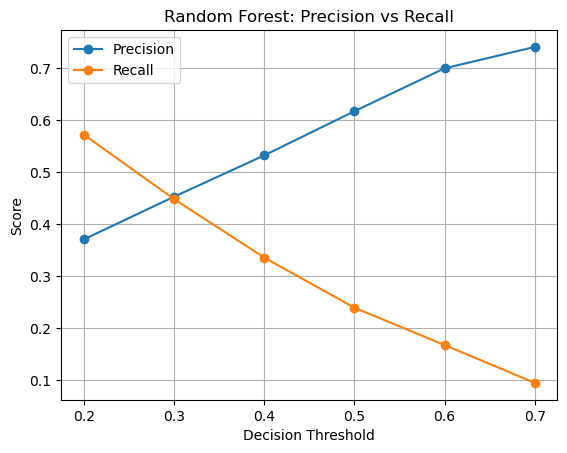

In [18]:
# Random Forest precision and recall by threshold

plt.plot(
    rf_threshold_results["Threshold"],
    rf_threshold_results["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    rf_threshold_results["Threshold"],
    rf_threshold_results["Recall"],
    marker="o",
    label="Recall"
)

plt.xlabel("Decision Threshold")
plt.ylabel("Score")
plt.title("Random Forest: Precision vs Recall")
plt.legend()
plt.grid(True)

plt.show()